In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##  1 .LOAD DATA

In [2]:
df = pd.read_csv('car data.csv')

print("=" * 60)
print(" DATA OVERVIEW")
print("=" * 60)

print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

print("\nFirst 3 Records:")
print(df.head(3).to_string())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

 DATA OVERVIEW
Rows: 301 | Columns: 9

First 3 Records:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type Transmission  Owner
0     ritz  2014           3.35           5.59       27000    Petrol       Dealer       Manual      0
1      sx4  2013           4.75           9.54       43000    Diesel       Dealer       Manual      0
2     ciaz  2017           7.25           9.85        6900    Petrol       Dealer       Manual      0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmiss

## 2. FEATURE ENGINEERING

In [14]:
df = pd.read_csv("car data.csv")

print("\n" + "=" * 60)
print(" FEATURE ENGINEERING")
print("=" * 60)

from datetime import datetime

# Current year
current_year = datetime.now().year

# Feature 1: Car Age
df["Car_Age"] = current_year - df["Year"]

# Feature 2: Kilometers driven per year
df["KMs_Per_Year"] = df["Driven_kms"] / (df["Car_Age"] + 1)

# Feature 3: Whether the car is relatively recent
df["Is_Recent_Car"] = (df["Car_Age"] <= 10).astype(int)

# Feature 4: Extract brand from car name
df["Brand"] = df["Car_Name"].apply(lambda x: x.split()[0])

# Save original dataframe for visualizations
df_vis = df.copy()

print("New features created:")
print("- Car_Age")
print("- KMs_Per_Year")
print("- Is_Recent_Car")
print("- Brand")

print("\nFeature Summary:")
print(
    df[["Car_Age", "KMs_Per_Year", "Is_Recent_Car"]]
    .describe()
    .round(2)
    .to_string()
)

print("\nRecent Car Distribution:")
print(df["Is_Recent_Car"].value_counts())



 FEATURE ENGINEERING
New features created:
- Car_Age
- KMs_Per_Year
- Is_Recent_Car
- Brand

Feature Summary:
       Car_Age  KMs_Per_Year  Is_Recent_Car
count   301.00        301.00         301.00
mean     12.37       2588.36           0.29
std       2.89       2148.47           0.45
min       8.00         45.45           0.00
25%      10.00       1269.23           0.00
50%      12.00       2357.14           0.00
75%      14.00       3429.27           1.00
max      23.00      26315.79           1.00

Recent Car Distribution:
Is_Recent_Car
0    215
1     86
Name: count, dtype: int64


##  3. PREPROCESSING

In [15]:
print("\n" + "=" * 60)
print(" PREPROCESSING")
print("=" * 60)

# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=["Brand", "Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

# Feature selection
feature_cols = [
    col for col in df.columns
    if col not in ["Car_Name", "Year", "Selling_Price"]
]

# Features and target
X = df[feature_cols]
y = df["Selling_Price"]

print(f"\nNumber of Features: {len(feature_cols)}")

print("\nFeatures Used:")
print(feature_cols)

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Vector Shape : {y.shape}")


 PREPROCESSING

Number of Features: 53

Features Used:
['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'KMs_Per_Year', 'Is_Recent_Car', 'Brand_Activa', 'Brand_Bajaj', 'Brand_Hero', 'Brand_Honda', 'Brand_Hyosung', 'Brand_KTM', 'Brand_Mahindra', 'Brand_Royal', 'Brand_Suzuki', 'Brand_TVS', 'Brand_UM', 'Brand_Yamaha', 'Brand_alto', 'Brand_amaze', 'Brand_baleno', 'Brand_brio', 'Brand_camry', 'Brand_ciaz', 'Brand_city', 'Brand_corolla', 'Brand_creta', 'Brand_dzire', 'Brand_elantra', 'Brand_eon', 'Brand_ertiga', 'Brand_etios', 'Brand_fortuner', 'Brand_grand', 'Brand_i10', 'Brand_i20', 'Brand_ignis', 'Brand_innova', 'Brand_jazz', 'Brand_land', 'Brand_omni', 'Brand_ritz', 'Brand_s', 'Brand_swift', 'Brand_sx4', 'Brand_verna', 'Brand_vitara', 'Brand_wagon', 'Brand_xcent', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']

Feature Matrix Shape: (301, 53)
Target Vector Shape : (301,)


## 4. TRAIN / TEST SPLIT

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")



Train set: 240 samples | Test set: 61 samples


## 5. MODEL TRAINING & EVALUATION

In [26]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

In [27]:
print("\n" + "=" * 60)
print(" MODEL TRAINING & EVALUATION")
print("=" * 60)

# Cross-validation strategy
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = {}
predictions = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Cross-validation
    cv_score = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    ).mean()

    # Store results
    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "CV R²": cv_score
    }

    print(f"\n{name}")
    print(f"MAE      : ₹{mae:.4f}L")
    print(f"RMSE     : ₹{rmse:.4f}L")
    print(f"R² Score : {r2:.4f}")
    print(f"CV R²    : {cv_score:.4f}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]["R²"])
best_model = models[best_model_name]

print("\n" + "=" * 60)
print(f" BEST MODEL: {best_model_name}")
print(f"R² Score: {results[best_model_name]['R²']:.4f}")
print("=" * 60)


 MODEL TRAINING & EVALUATION

Linear Regression
MAE      : ₹1.1850L
RMSE     : ₹1.7928L
R² Score : 0.8605
CV R²    : 0.7866

Random Forest
MAE      : ₹0.6173L
RMSE     : ₹0.9293L
R² Score : 0.9625
CV R²    : 0.9217

Gradient Boosting
MAE      : ₹0.5864L
RMSE     : ₹0.9589L
R² Score : 0.9601
CV R²    : 0.9262

 BEST MODEL: Random Forest
R² Score: 0.9625


## BEST MODEL

In [28]:
best_model_name = max(
    results,
    key=lambda x: results[x]["R²"]
)

best_model = models[best_model_name]

print("\n" + "=" * 60)
print(" BEST MODEL")
print("=" * 60)

print(
    f"Best Model: {best_model_name}"
)

print(
    f"R² Score : {results[best_model_name]['R²']:.4f}"
)


 BEST MODEL
Best Model: Random Forest
R² Score : 0.9625


## 6. FEATURE IMPORTANCE (best model if RF/GB)


 FEATURE IMPORTANCE
Present_Price             ███████████████████████████████████████████ 0.8646
Car_Age                   ██ 0.0512
Driven_kms                █ 0.0247
KMs_Per_Year               0.0116
Transmission_Manual        0.0084
Brand_land                 0.0079
Brand_fortuner             0.0063
Is_Recent_Car              0.0044
Brand_innova               0.0036
Brand_city                 0.0034


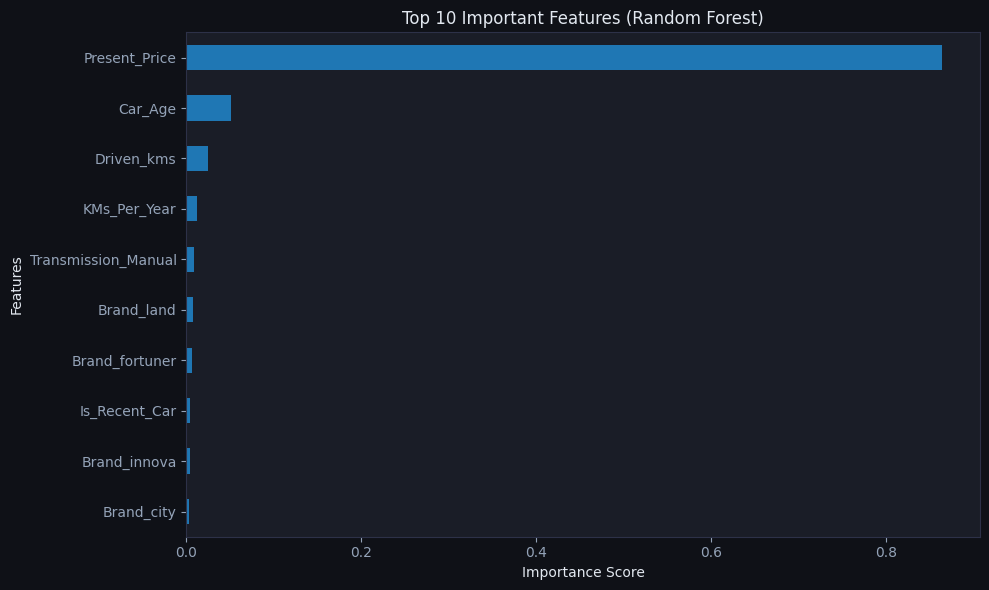

In [29]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

if hasattr(best_model, "feature_importances_"):

    importances = pd.Series(
        best_model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

    print("\n" + "=" * 60)
    print(" FEATURE IMPORTANCE")
    print("=" * 60)

    for feat, imp in importances.head(10).items():
        bar = "█" * int(imp * 50)
        print(f"{feat:<25} {bar} {imp:.4f}")

    # Visualization
    plt.figure(figsize=(10, 6))

    importances.head(10).sort_values().plot(
        kind="barh"
    )

    plt.title(f"Top 10 Important Features ({best_model_name})")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")

    plt.tight_layout()
    plt.show()


## 7. VISUALIZATIONS 

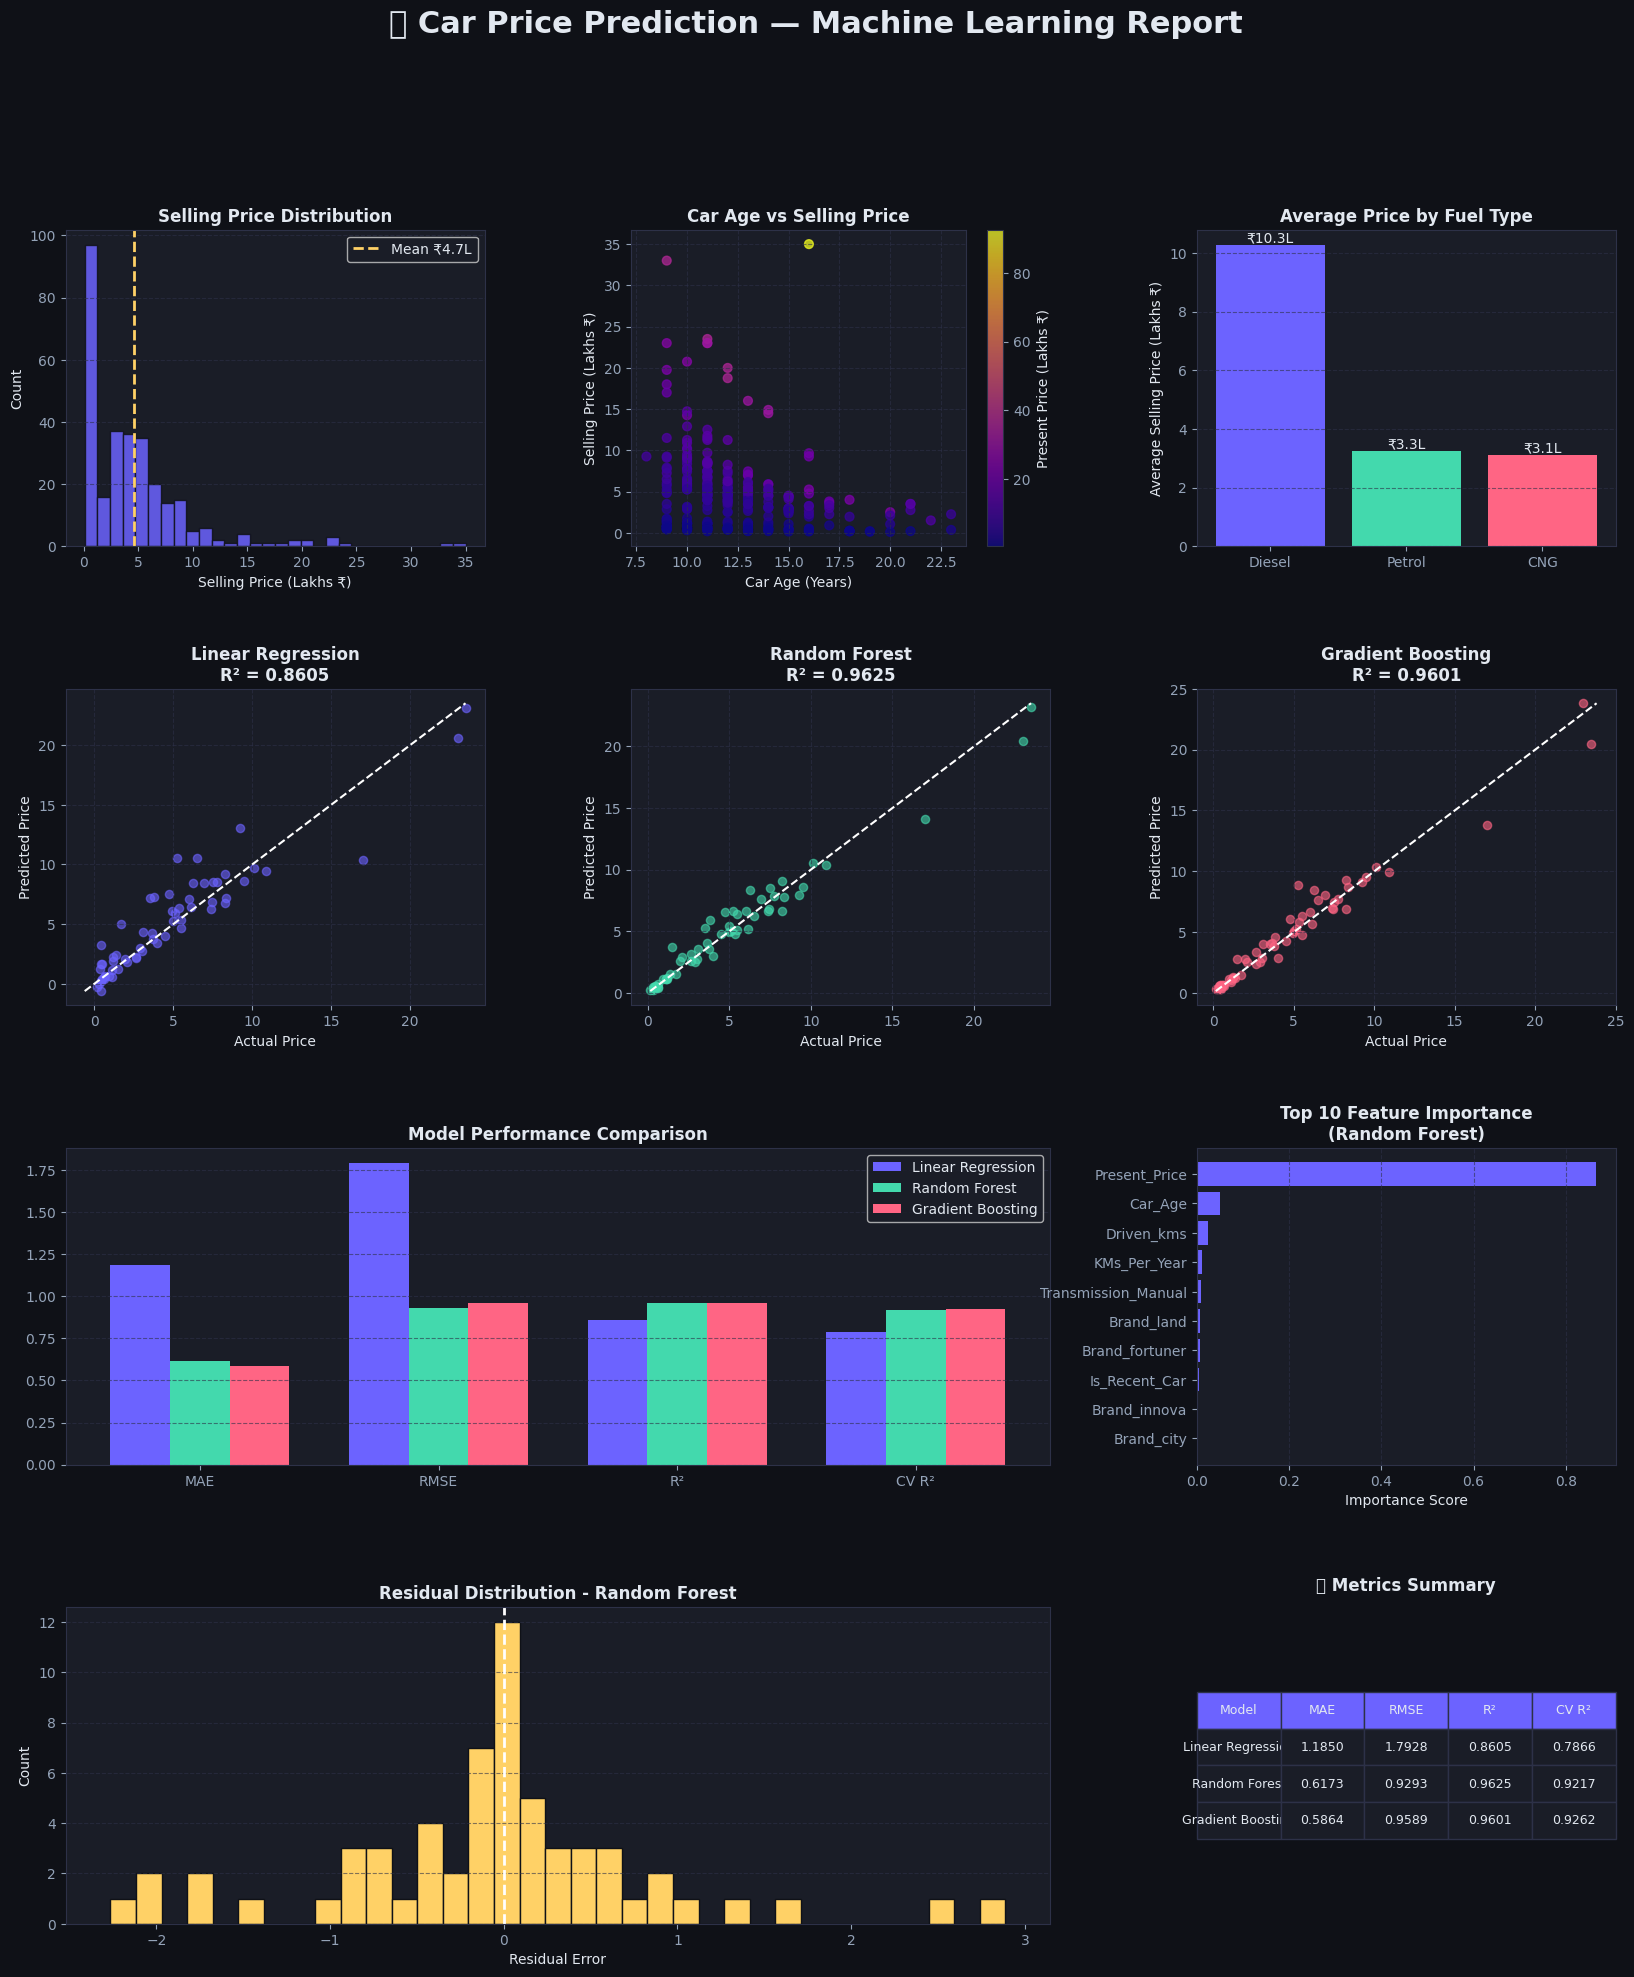

In [34]:
# ============================================================
# PROFESSIONAL ML DASHBOARD
# ============================================================

# Create feature importance series (if available)
importances = None

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(
        best_model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

# Color Palette
PALETTE = {
    "bg": "#0f1117",
    "panel": "#1a1d27",
    "accent1": "#6c63ff",
    "accent2": "#ff6584",
    "accent3": "#43d9ad",
    "accent4": "#ffd166",
    "text": "#e2e8f0",
    "subtext": "#94a3b8",
    "grid": "#2d3148",
}

# Global Styling
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor": PALETTE["panel"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["text"],
    "xtick.color": PALETTE["subtext"],
    "ytick.color": PALETTE["subtext"],
    "text.color": PALETTE["text"],
    "grid.color": PALETTE["grid"],
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "font.family": "DejaVu Sans",
})

# Create Figure
fig = plt.figure(figsize=(20, 22), facecolor=PALETTE["bg"])

fig.suptitle(
    "🚗 Car Price Prediction — Machine Learning Report",
    fontsize=22,
    fontweight="bold",
    color=PALETTE["text"],
    y=0.98
)

gs = gridspec.GridSpec(
    4, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

# ============================================================
# PANEL 1: Selling Price Distribution
# ============================================================

ax1 = fig.add_subplot(gs[0, 0])

ax1.hist(
    df["Selling_Price"],
    bins=30,
    color=PALETTE["accent1"],
    edgecolor=PALETTE["bg"],
    alpha=0.85
)

ax1.axvline(
    df["Selling_Price"].mean(),
    color=PALETTE["accent4"],
    linestyle="--",
    linewidth=2,
    label=f"Mean ₹{df['Selling_Price'].mean():.1f}L"
)

ax1.set_title(
    "Selling Price Distribution",
    fontweight="bold"
)

ax1.set_xlabel("Selling Price (Lakhs ₹)")
ax1.set_ylabel("Count")
ax1.legend()
ax1.grid(True, axis="y")

# ============================================================
# PANEL 2: Car Age vs Selling Price
# ============================================================

ax2 = fig.add_subplot(gs[0, 1])

sc = ax2.scatter(
    df["Car_Age"],
    df["Selling_Price"],
    c=df["Present_Price"],
    cmap="plasma",
    alpha=0.75,
    s=40
)

plt.colorbar(
    sc,
    ax=ax2,
    label="Present Price (Lakhs ₹)"
)

ax2.set_title(
    "Car Age vs Selling Price",
    fontweight="bold"
)

ax2.set_xlabel("Car Age (Years)")
ax2.set_ylabel("Selling Price (Lakhs ₹)")
ax2.grid(True)

# ============================================================
# PANEL 3: Average Price by Fuel Type
# ============================================================

ax3 = fig.add_subplot(gs[0, 2])

fuel_avg = (
    df_vis.groupby("Fuel_Type")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

colors_bar = [
    PALETTE["accent1"],
    PALETTE["accent3"],
    PALETTE["accent2"]
]

bars = ax3.bar(
    fuel_avg.index,
    fuel_avg.values,
    color=colors_bar[:len(fuel_avg)]
)

for bar, val in zip(bars, fuel_avg.values):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"₹{val:.1f}L",
        ha="center"
    )

ax3.set_title(
    "Average Price by Fuel Type",
    fontweight="bold"
)

ax3.set_ylabel("Average Selling Price (Lakhs ₹)")
ax3.grid(True, axis="y")

# ============================================================
# PANEL 4-6: Actual vs Predicted
# ============================================================

model_colors = [
    PALETTE["accent1"],
    PALETTE["accent3"],
    PALETTE["accent2"]
]

for i, (mname, mpred) in enumerate(predictions.items()):

    ax = fig.add_subplot(gs[1, i])

    ax.scatter(
        y_test,
        mpred,
        color=model_colors[i],
        alpha=0.6,
        s=35
    )

    lims = [
        min(y_test.min(), mpred.min()),
        max(y_test.max(), mpred.max())
    ]

    ax.plot(
        lims,
        lims,
        "w--",
        linewidth=1.5
    )

    ax.set_title(
        f"{mname}\nR² = {results[mname]['R²']:.4f}",
        fontweight="bold"
    )

    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.grid(True)

# ============================================================
# PANEL 7: Model Comparison
# ============================================================

ax7 = fig.add_subplot(gs[2, :2])

metrics = ["MAE", "RMSE", "R²", "CV R²"]

x = np.arange(len(metrics))
bar_width = 0.25

for i, (mname, mres) in enumerate(results.items()):

    values = [mres[m] for m in metrics]

    ax7.bar(
        x + i*bar_width,
        values,
        width=bar_width,
        label=mname,
        color=model_colors[i]
    )

ax7.set_title(
    "Model Performance Comparison",
    fontweight="bold"
)

ax7.set_xticks(x + bar_width)
ax7.set_xticklabels(metrics)

ax7.legend()
ax7.grid(True, axis="y")

# ============================================================
# PANEL 8: Feature Importance
# ============================================================

ax8 = fig.add_subplot(gs[2, 2])

if importances is not None:

    imp_sorted = importances.head(10).sort_values()

    ax8.barh(
        imp_sorted.index,
        imp_sorted.values,
        color=PALETTE["accent1"]
    )

    ax8.set_title(
        f"Top 10 Feature Importance\n({best_model_name})",
        fontweight="bold"
    )

    ax8.set_xlabel("Importance Score")
    ax8.grid(True, axis="x")

else:

    ax8.text(
        0.5,
        0.5,
        "Feature Importance\nNot Available",
        ha="center",
        va="center",
        fontsize=12
    )

    ax8.axis("off")

# ============================================================
# PANEL 9: Residual Distribution
# ============================================================

ax9 = fig.add_subplot(gs[3, :2])

best_pred = predictions[best_model_name]

residuals = y_test.values - best_pred

ax9.hist(
    residuals,
    bins=35,
    color=PALETTE["accent4"],
    edgecolor=PALETTE["bg"]
)

ax9.axvline(
    0,
    color="white",
    linestyle="--",
    linewidth=2
)

ax9.set_title(
    f"Residual Distribution - {best_model_name}",
    fontweight="bold"
)

ax9.set_xlabel("Residual Error")
ax9.set_ylabel("Count")
ax9.grid(True, axis="y")

# ============================================================
# PANEL 10: Summary Table
# ============================================================

ax10 = fig.add_subplot(gs[3, 2])
ax10.axis("off")

table_data = [
    [name] + [f"{results[name][m]:.4f}"
              for m in ["MAE", "RMSE", "R²", "CV R²"]]
    for name in results
]

tbl = ax10.table(
    cellText=table_data,
    colLabels=["Model", "MAE", "RMSE", "R²", "CV R²"],
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.2)

for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor(
        PALETTE["panel"] if row > 0 else PALETTE["accent1"]
    )

    cell.set_edgecolor(PALETTE["grid"])

    cell.set_text_props(
        color=PALETTE["text"]
    )

ax10.set_title(
    "📊 Metrics Summary",
    fontweight="bold",
    pad=12
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save dashboard as high-quality PNG
plt.savefig(
    "car_price_ml_dashboard.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


## 8. SAMPLE PREDICTIONS

In [31]:
print("\n" + "=" * 60)
print(" SAMPLE PREDICTIONS (Best Model)")
print("=" * 60)

sample = X_test.head(8).copy()
actual = y_test.head(8).values
predicted = best_model.predict(sample)

for i, (act, pred) in enumerate(zip(actual, predicted), start=1):

    diff = act - pred

    if abs(diff) < 1:
        icon = "✅"
    elif abs(diff) < 2:
        icon = "⚠️"
    else:
        icon = "❌"

    print(
        f"{i}. {icon} Actual: ₹{act:.2f}L | "
        f"Predicted: ₹{pred:.2f}L | "
        f"Error: ₹{diff:+.2f}L"
    )


 SAMPLE PREDICTIONS (Best Model)
1. ✅ Actual: ₹0.35L | Predicted: ₹0.44L | Error: ₹-0.09L
2. ✅ Actual: ₹10.11L | Predicted: ₹10.55L | Error: ₹-0.44L
3. ✅ Actual: ₹4.95L | Predicted: ₹4.98L | Error: ₹-0.03L
4. ✅ Actual: ₹0.15L | Predicted: ₹0.21L | Error: ₹-0.06L
5. ✅ Actual: ₹6.95L | Predicted: ₹7.64L | Error: ₹-0.69L
6. ✅ Actual: ₹7.45L | Predicted: ₹6.81L | Error: ₹+0.64L
7. ✅ Actual: ₹1.10L | Predicted: ₹1.09L | Error: ₹+0.01L
8. ✅ Actual: ₹0.50L | Predicted: ₹0.60L | Error: ₹-0.10L


In [32]:
pd.DataFrame(results).T.sort_values(
    by="R²",
    ascending=False
)

,MAE,RMSE,R²,CV R²
Random Forest,0.617331,0.929296,0.962511,0.921711
Gradient Boosting,0.586443,0.958855,0.960088,0.926238
Linear Regression,1.184958,1.792806,0.860470,0.786569
